In [ ]:
import kagglehub
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os

ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']

In [ ]:

dataset_path = kagglehub.dataset_download("datamunge/sign-language-mnist")
csv_file = os.path.join(dataset_path, "sign_mnist_train.csv")

In [ ]:
df = pd.read_csv(csv_file)
features = df.drop('label', axis=1).values

real_images = torch.tensor(features).float()
real_images = (real_images - 127.5) / 127.5
real_images = real_images.view(-1, 1, 28, 28)

dataloader = torch.utils.data.DataLoader(real_images, batch_size=128, shuffle=True)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()        
        self.fc = nn.Linear(100, 256 * 7 * 7)
        self.conv = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh() 
        )

    def forward(self, x):
        x = self.fc(x).view(-1, 256, 7, 7)
        return self.conv(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
       
        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv(x).view(-1, 128 * 7 * 7)
        return self.fc(x)

gen = Generator()
disc = Discriminator()

In [7]:

opt_g = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_d = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()


In [8]:
epochs = 3

In [11]:
for epoch in range(epochs):
    for i, real_batch in enumerate(dataloader):
        batch_size = real_batch.size(0)
        
       
        opt_d.zero_grad()
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)
        
        # Real pass
        out_real = disc(real_batch)
        loss_real = criterion(out_real, real_labels)
        
        # Fake pass
        noise = torch.randn(batch_size, 100)
        fake_imgs = gen(noise)
        out_fake = disc(fake_imgs.detach())
        loss_fake = criterion(out_fake, fake_labels)
        
        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()


        acc_real = (out_real > 0.5).float().mean().item()
        acc_fake = (out_fake < 0.5).float().mean().item()
        d_acc = (acc_real + acc_fake) / 2
        
    
        opt_g.zero_grad()
       
        out_g = disc(fake_imgs)
        loss_g = criterion(out_g, real_labels)
        loss_g.backward()
        opt_g.step()
        
 
        g_acc = (out_g > 0.5).float().mean().item()

    print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_d:.4f}, Loss G: {loss_g:.4f} | D Acc: {d_acc:.2%}")

Epoch [1/3] | Loss D: 0.2378, Loss G: 3.5831 | D Acc: 96.83%
Epoch [2/3] | Loss D: 0.2700, Loss G: 2.6129 | D Acc: 99.21%
Epoch [3/3] | Loss D: 2.0153, Loss G: 3.9935 | D Acc: 50.00%


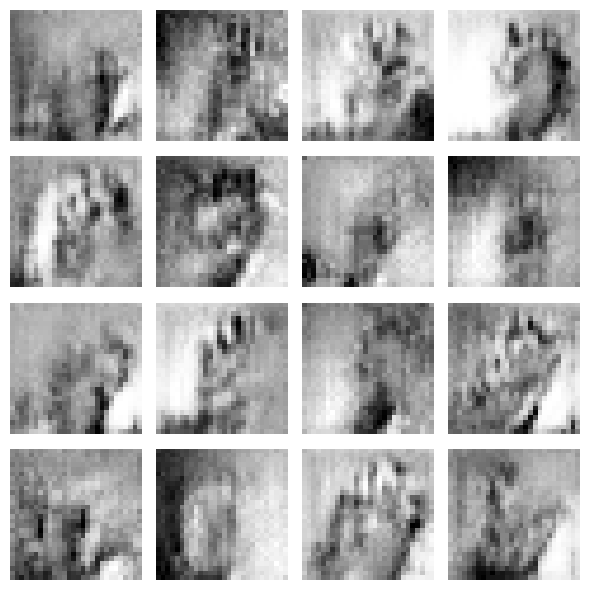

In [12]:

test_noise = torch.randn(16, 100)
final_fakes = gen(test_noise).detach()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
 
    img = final_fakes[i].view(28, 28) * 0.5 + 0.5
    ax.imshow(img.numpy(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()